# Pipeline VMD-SSA-LSTM para predicción de tendencia bursátil

Pipeline completo: ingesta → limpieza → normalización sliding-window → VMD (selección K/α por SNR) → ingeniería de features → optimización de hiperparámetros LSTM con SSA (DevSSA) → entrenamiento → evaluación.

**Orden de ejecución:** ejecutar las celdas de arriba a abajo. Las variables globales se propagan entre secciones.

In [ ]:
# Instalar dependencias (ejecutar solo si es necesario)
!pip install vmdpy mealpy torch scikit-learn pandas numpy matplotlib seaborn --quiet --upgrade --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving AAPL.csv to AAPL (1).csv


In [ ]:
import os, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from itertools import product

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from vmdpy import VMD
from mealpy import FloatVar, IntegerVar
from mealpy.swarm_based import SSA

from sklearn.metrics import (r2_score, mean_absolute_error,
                              mean_squared_error, f1_score, confusion_matrix)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.11.0+cu130


---
## 1 · Ingesta de datos

Cargar el CSV del ticker elegido. Cambiar `TICKER` y `DATA_PATH` para trabajar con cualquier acción del dataset.
Las columnas esperadas son: `ticker, date, open, high, low, close`.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN  ←  modificar aquí para cambiar de ticker o ruta
# ══════════════════════════════════════════════════════════════════════
TICKER    = 'AAPL'
DATA_PATH = f'{TICKER}.csv'   # ajustar ruta si fuera necesario

FEATURES = ['open', 'high', 'low', 'close']   # orden fijo en todo el notebook

In [ ]:
df = pd.read_csv(DATA_PATH)

# Asegurar que 'date' es datetime y está como índice
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')

# Conservar solo columnas OHLC (descartar 'ticker' si está presente)
df = df[FEATURES]

print(f'Ticker   : {TICKER}')
print(f'Columnas : {list(df.columns)}')
print(f'Forma    : {df.shape}')
print(f'Rango    : {df.index.min().date()}  →  {df.index.max().date()}')

Ticker   : AAPL
Columnas : ['open', 'high', 'low', 'close']
Forma    : (11385, 4)
Rango    : 1980-12-12  →  2026-03-27


In [ ]:
print('Primeras filas:')
display(df.head(8))
print('\nÚltimas filas:')
display(df.tail(5))
print('\nEstadísticas descriptivas:')
display(df.describe().round(4))

Primeras filas:


,open,high,low,close
date,,,,
1980-12-12,0.13,0.13,0.13,0.13
1980-12-15,0.12,0.12,0.12,0.12
1980-12-16,0.11,0.11,0.11,0.11
1980-12-17,0.12,0.12,0.12,0.12
1980-12-18,0.12,0.12,0.12,0.12
1980-12-19,0.13,0.13,0.13,0.13
1980-12-22,0.13,0.13,0.13,0.13
1980-12-23,0.14,0.14,0.14,0.14



Últimas filas:


,open,high,low,close
date,,,,
2026-03-23,254.160,254.600,250.28,251.49
2026-03-24,250.350,254.825,249.55,251.64
2026-03-25,254.095,255.000,251.60,252.62
2026-03-26,252.115,257.000,250.77,252.89
2026-03-27,253.900,255.493,248.07,248.80



Estadísticas descriptivas:


,open,high,low,close
count,11385.0000,11385.0000,11385.0000,11385.0000
mean,28.8891,29.2025,28.5958,28.9113
std,59.5068,60.1470,58.9228,59.5601
min,0.0500,0.0500,0.0500,0.0500
25%,0.2600,0.2661,0.2551,0.2600
50%,0.5042,0.5146,0.4935,0.5033
75%,22.0727,22.2760,21.8484,22.0747
max,286.2000,288.6200,283.3000,286.1900


---
## 2 · Preprocesamiento y limpieza de datos

Aplicamos reglas de calidad generales que son válidas para cualquier ticker:
nulos, duplicados, coherencia OHLC, precios no positivos, filas con O=H=L=C y gaps temporales.

In [ ]:
print('═' * 50)
print('2.1  NULOS')
print('═' * 50)
nulls = df.isnull().sum()
print(nulls.to_string())
if nulls.any():
    n_before = len(df)
    df = df.dropna()
    print(f'\n→ Eliminadas {n_before - len(df)} filas con NaN. Forma: {df.shape}')
else:
    print('\n→ Sin valores nulos.')

══════════════════════════════════════════════════
2.1  NULOS
══════════════════════════════════════════════════
open     0
high     0
low      0
close    0

→ Sin valores nulos.


In [ ]:
print('═' * 50)
print('2.2  FECHAS DUPLICADAS')
print('═' * 50)
n_dup = df.index.duplicated().sum()
print(f'Fechas duplicadas: {n_dup}')
if n_dup > 0:
    df = df[~df.index.duplicated(keep='first')]
    print(f'→ Eliminados. Forma: {df.shape}')
else:
    print('→ Sin duplicados.')

══════════════════════════════════════════════════
2.2  FECHAS DUPLICADAS
══════════════════════════════════════════════════
Fechas duplicadas: 0
→ Sin duplicados.


In [ ]:
print('═' * 50)
print('2.3  COHERENCIA OHLC + PRECIOS POSITIVOS')
print('═' * 50)

# Low ≤ Open, Low ≤ Close, Close ≤ High, todos > 0
bad_low_open  = df['low']  > df['open']
bad_low_close = df['low']  > df['close']
bad_hi_close  = df['high'] < df['close']
bad_positive  = (df[FEATURES] <= 0).any(axis=1)
invalid = bad_low_open | bad_low_close | bad_hi_close | bad_positive

print(f'  low > open    : {bad_low_open.sum():5d}')
print(f'  low > close   : {bad_low_close.sum():5d}')
print(f'  high < close  : {bad_hi_close.sum():5d}')
print(f'  precio ≤ 0    : {bad_positive.sum():5d}')
print(f'  Total inválido: {invalid.sum():5d}')

if invalid.any():
    df = df[~invalid]
    print(f'\n→ Filas inválidas eliminadas. Forma: {df.shape}')

══════════════════════════════════════════════════
2.3  COHERENCIA OHLC + PRECIOS POSITIVOS
══════════════════════════════════════════════════
  low > open    :     0
  low > close   :     0
  high < close  :     0
  precio ≤ 0    :     0
  Total inválido:     0


In [ ]:
print('═' * 50)
print('2.4  FILAS CON O = H = L = C  (posible baja calidad)')
print('═' * 50)

# ─── Parámetro: True elimina estas filas, False las conserva ─────────────────
DROP_FLAT_ROWS = False

flat_mask = (
    (df['open'] == df['high']) &
    (df['high'] == df['low'])  &
    (df['low']  == df['close'])
)
n_flat = flat_mask.sum()
print(f'Filas con O=H=L=C: {n_flat}')

if n_flat > 0:
    flat_years = df[flat_mask].index.year.value_counts().sort_index()
    print('\nDistribución por año:')
    print(flat_years.to_string())
    print(f'\nPrimera fecha flat: {df[flat_mask].index.min().date()}')
    print(f'Última  fecha flat: {df[flat_mask].index.max().date()}')

    if DROP_FLAT_ROWS:
        df = df[~flat_mask]
        print(f'\n[DROP_FLAT_ROWS=True] → Eliminadas {n_flat} filas. Forma: {df.shape}')
    else:
        print('\n[DROP_FLAT_ROWS=False] → Conservadas.')
else:
    print('→ No hay filas flat.')

══════════════════════════════════════════════════
2.4  FILAS CON O = H = L = C  (posible baja calidad)
══════════════════════════════════════════════════
Filas con O=H=L=C: 639

Distribución por año:
date
1980     13
1981    235
1982    206
1983     78
1984     81
1985     25
2025      1

Primera fecha flat: 1980-12-12
Última  fecha flat: 2025-07-11

[DROP_FLAT_ROWS=False] → Conservadas.


In [ ]:
print('═' * 50)
print('2.5  GAPS TEMPORALES (> 7 días)')
print('═' * 50)

diff_days = df.index.to_series().diff().dt.days
gaps = diff_days[diff_days > 7].sort_values(ascending=False)
print(f'Gaps > 7 días encontrados: {len(gaps)}')
if len(gaps) > 0:
    print('\nTop 10 gaps:')
    display(gaps.head(10).rename('días').to_frame())
else:
    print('→ Sin gaps significativos.')

══════════════════════════════════════════════════
2.5  GAPS TEMPORALES (> 7 días)
══════════════════════════════════════════════════
Gaps > 7 días encontrados: 1

Top 10 gaps:


,días
date,
2025-01-27,49.0


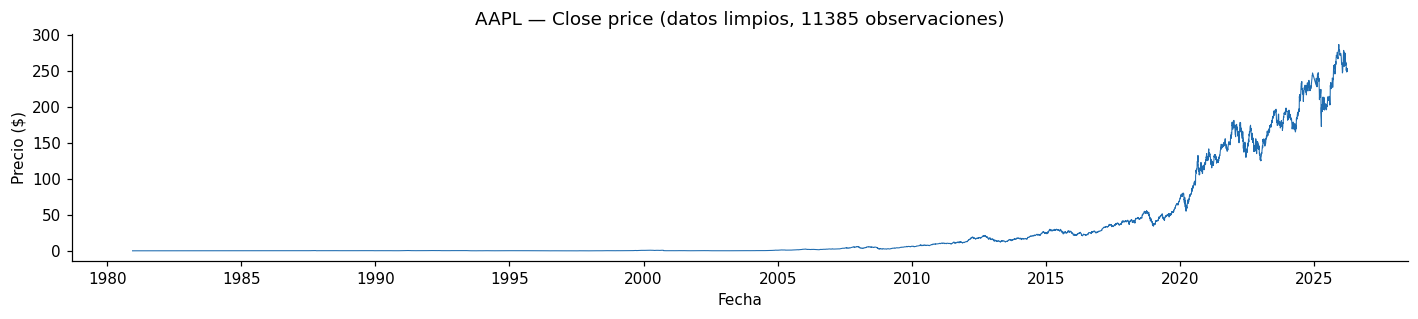

Total observaciones limpias: 11385


In [ ]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df.index, df['close'], lw=0.7, color='#1f6cb0')
ax.set_title(f'{TICKER} — Close price (datos limpios, {len(df)} observaciones)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ($)')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()
print(f'Total observaciones limpias: {len(df)}')

---
## 3 · Split temporal 70 / 15 / 15

Partición cronológica estricta, **sin shuffle** en ninguna fase.
La normalización se aplica en la siguiente sección, siempre posterior al split para evitar cualquier fuga de datos.

In [ ]:
N = len(df)
n_train = int(N * 0.70)
n_val   = int(N * 0.15)
n_test  = N - n_train - n_val

df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val :]

print(f'Total  : {N:6d} observaciones')
print(f'Train  : {len(df_train):6d}  [{df_train.index[0].date()} → {df_train.index[-1].date()}]')
print(f'Val    : {len(df_val):6d}  [{df_val.index[0].date()}   → {df_val.index[-1].date()}]')
print(f'Test   : {len(df_test):6d}  [{df_test.index[0].date()}   → {df_test.index[-1].date()}]')

Total  :  11385 observaciones
Train  :   7969  [1980-12-12 → 2012-07-12]
Val    :   1707  [2012-07-13   → 2019-04-26]
Test   :   1709  [2019-04-29   → 2026-03-27]


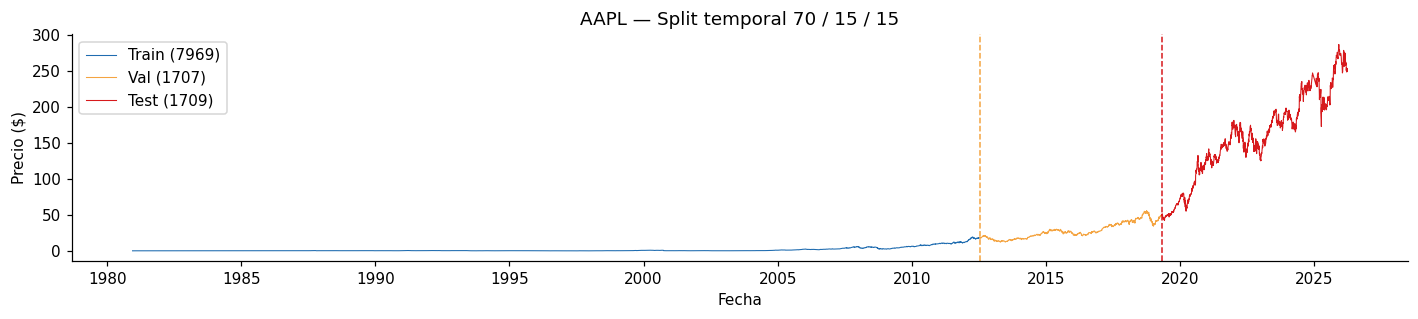

In [ ]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df_train.index, df_train['close'], lw=0.7, color='#1f6cb0', label=f'Train ({len(df_train)})')
ax.plot(df_val.index,   df_val['close'],   lw=0.7, color='#f4a441', label=f'Val ({len(df_val)})')
ax.plot(df_test.index,  df_test['close'],  lw=0.7, color='#d7191c', label=f'Test ({len(df_test)})')
for x, c in [(df_val.index[0], '#f4a441'), (df_test.index[0], '#d7191c')]:
    ax.axvline(x, color=c, ls='--', lw=1)
ax.set_title(f'{TICKER} — Split temporal 70 / 15 / 15')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ($)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4 · Normalización por ventana deslizante (Min-Max)

Para cada punto `t` se normaliza usando el `[min, max]` de los `WINDOW_SIZE` días anteriores `[t-W, t-1]`.
Esto garantiza que cada muestra solo usa información pasada (sin data leakage).

La normalización se aplica al dataset completo (los primeros `WINDOW_SIZE` puntos se descartan por no tener ventana completa).
Se almacenan los parámetros `(w_min, w_max)` de cada paso para poder realizar la transformación inversa sobre las predicciones.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  PARÁMETRO: tamaño de ventana  (252 días hábiles ≈ 1 año de trading)
# ══════════════════════════════════════════════════════════════════════
WINDOW_SIZE = 252

def sliding_window_normalize(data: np.ndarray, window_size: int):
    """
    Normalización Min-Max con ventana deslizante backward-looking.

    Parámetros
    ----------
    data        : array (N, n_features)
    window_size : número de pasos históricos para calcular min/max

    Devuelve
    --------
    normalized  : array (N - window_size, n_features)  en [0, 1]
    scale_params: list de (w_min, w_max) por cada paso válido
    """
    n = len(data)
    result = np.zeros((n - window_size, data.shape[1]), dtype=np.float32)
    scale_params = []

    for t in range(window_size, n):
        window  = data[t - window_size : t]          # [t-W, t-1]
        w_min   = window.min(axis=0)
        w_max   = window.max(axis=0)
        w_range = w_max - w_min
        w_range[w_range < 1e-8] = 1.0               # evitar división por cero
        result[t - window_size] = (data[t] - w_min) / w_range
        scale_params.append((w_min.copy(), w_max.copy()))

    return result, scale_params


def inverse_transform_close(norm_value, scale_entry, close_idx=3):
    """
    Deshace la normalización para la columna Close.

    Parámetros
    ----------
    norm_value  : valor normalizado
    scale_entry : (w_min, w_max) correspondiente a ese paso
    close_idx   : índice de 'close' en FEATURES (default 3)
    """
    w_min, w_max = scale_entry
    return norm_value * (w_max[close_idx] - w_min[close_idx]) + w_min[close_idx]


print('Funciones de normalización definidas.')

Funciones de normalización definidas.


In [ ]:
# Aplicar al dataset completo (cada punto solo usa datos pasados → sin leakage)
data_all = df[FEATURES].values.astype(np.float32)
data_norm, scale_params = sliding_window_normalize(data_all, WINDOW_SIZE)

# DataFrame normalizado con fechas correctas
dates_norm = df.index[WINDOW_SIZE:]
df_norm = pd.DataFrame(data_norm, index=dates_norm, columns=FEATURES)

# Re-calcular split sobre datos normalizados
N2      = len(df_norm)
n_tr2   = int(N2 * 0.70)
n_val2  = int(N2 * 0.15)
n_te2   = N2 - n_tr2 - n_val2

train_norm = df_norm.iloc[:n_tr2].values
val_norm   = df_norm.iloc[n_tr2 : n_tr2 + n_val2].values
test_norm  = df_norm.iloc[n_tr2 + n_val2 :].values

# Parámetros de escala por partición (para la transformación inversa)
train_scale = scale_params[:n_tr2]
val_scale   = scale_params[n_tr2 : n_tr2 + n_val2]
test_scale  = scale_params[n_tr2 + n_val2 :]

print(f'Observaciones totales normalizadas : {N2}  (perdemos {WINDOW_SIZE} por ventana inicial)')
print(f'  train_norm : {train_norm.shape}')
print(f'  val_norm   : {val_norm.shape}')
print(f'  test_norm  : {test_norm.shape}')
print(f'\nRango valores normalizados  min={data_norm.min():.4f}  max={data_norm.max():.4f}')

Observaciones totales normalizadas : 11133  (perdemos 252 por ventana inicial)
  train_norm : (7793, 4)
  val_norm   : (1669, 4)
  test_norm  : (1671, 4)

Rango valores normalizados  min=-0.3071  max=1.3199


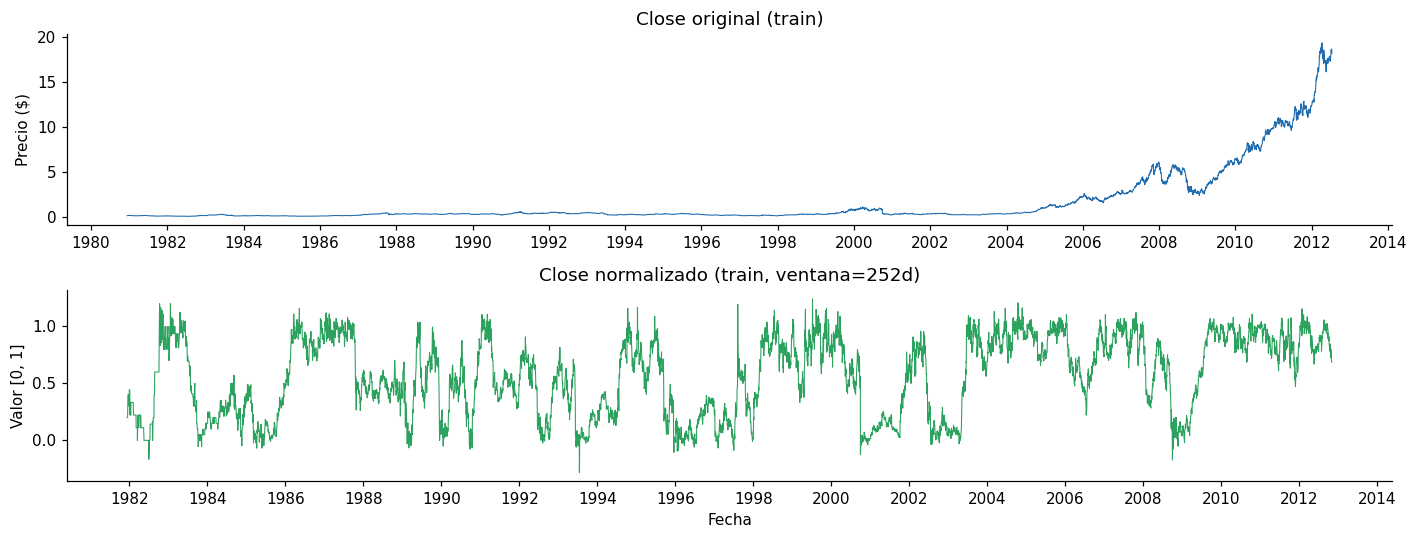

In [ ]:
# ── Visualización: Close original vs Close normalizado (train) ──────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=False)

idx_train = df_norm.index[:n_tr2]
close_col = FEATURES.index('close')

ax1.plot(df_train.index, df_train['close'], lw=0.7, color='#1f6cb0')
ax1.set_title('Close original (train)')
ax1.set_ylabel('Precio ($)')

ax2.plot(idx_train, train_norm[:, close_col], lw=0.7, color='#2ca25f')
ax2.set_title(f'Close normalizado (train, ventana={WINDOW_SIZE}d)')
ax2.set_ylabel('Valor [0, 1]')
ax2.set_xlabel('Fecha')

for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

---
## 5 · Descomposición VMD y selección de parámetros por SNR

**VMD (Variational Mode Decomposition)** descompone la señal Close en `K` modos (IMFs) de frecuencia decreciente.
Se aplica **solo sobre el precio de cierre normalizado**.

La búsqueda del par `(K, α)` óptimo se realiza maximizando el **SNR de reconstrucción**:

$$\text{SNR} = 10 \cdot \log_{10}\left(\frac{\text{var}(\text{señal})}{\text{var}(\text{señal} - \hat{\text{señal}})}\right)$$

Parámetros fijos según literatura: `τ=0`, `DC=0`, `init=1`, `tol=1e-7`.

In [ ]:
# ── Espacios de búsqueda ────────────────────────────────────────────────────
K_RANGE     = list(range(3, 13))            # K ∈ {3, 4, ..., 12}
ALPHA_RANGE = [1000, 2000, 3000, 4000, 5000, 6000, 7000]

# Parámetros VMD fijos (literatura)
VMD_TAU  = 0
VMD_DC   = 0
VMD_INIT = 1
VMD_TOL  = 1e-7

CLOSE_IDX = FEATURES.index('close')   # índice de la columna close

# Señal de entrenamiento para la búsqueda
train_close = train_norm[:, CLOSE_IDX].astype(np.float64)

if len(train_close) % 2:
  train_close = train_close[:-1] # VMD requiere longitud par


def compute_snr(signal: np.ndarray, imfs: np.ndarray) -> float:
    """
    SNR = 10 * log10( var(señal) / var(señal - reconstrucción) ).
    imfs tiene forma (K, N).
    """
    reconstruction = np.sum(imfs, axis=0)
    signal_aligned = signal[:len(reconstruction)] # alinear si VMD recorto 1 punto
    residual       = signal - reconstruction
    sig_power      = np.var(signal)
    res_power      = np.var(residual)
    if res_power < 1e-12:
        return 100.0
    return 10.0 * np.log10(sig_power / res_power)


print(f'Grid search: {len(K_RANGE)} valores de K × {len(ALPHA_RANGE)} valores de α = {len(K_RANGE)*len(ALPHA_RANGE)} combinaciones')

Grid search: 10 valores de K × 7 valores de α = 70 combinaciones


In [ ]:
# ── Grid search VMD ─────────────────────────────────────────────────────────
snr_grid = np.full((len(K_RANGE), len(ALPHA_RANGE)), np.nan)
t_search_start = time.time()

for i, K in enumerate(K_RANGE):
    for j, alpha in enumerate(ALPHA_RANGE):
        try:
            u, _, _ = VMD(train_close, alpha, VMD_TAU, K, VMD_DC, VMD_INIT, VMD_TOL)
            snr_grid[i, j] = compute_snr(train_close, u)
        except Exception as e:
            print(f"Warning: VMD failed for K={K}, alpha={alpha}. Error: {e}") # Added for debugging
            snr_grid[i, j] = np.nan   # combinación inestable

t_search = time.time() - t_search_start
print(f'Grid search completado en {t_search:.1f}s')

# ── Selección del mejor par ──────────────────────────────────────────────────
best_idx  = np.nanargmax(snr_grid)
best_i, best_j = np.unravel_index(best_idx, snr_grid.shape)
K_OPT     = K_RANGE[best_i]
ALPHA_OPT = ALPHA_RANGE[best_j]
SNR_BEST  = snr_grid[best_i, best_j]

print(f'\n► Parámetros óptimos VMD:')
print(f'   K     = {K_OPT}')
print(f'   α     = {ALPHA_OPT}')
print(f'   SNR   = {SNR_BEST:.4f} dB')

Grid search completado en 370.9s

► Parámetros óptimos VMD:
   K     = 12
   α     = 1000
   SNR   = 33.4557 dB


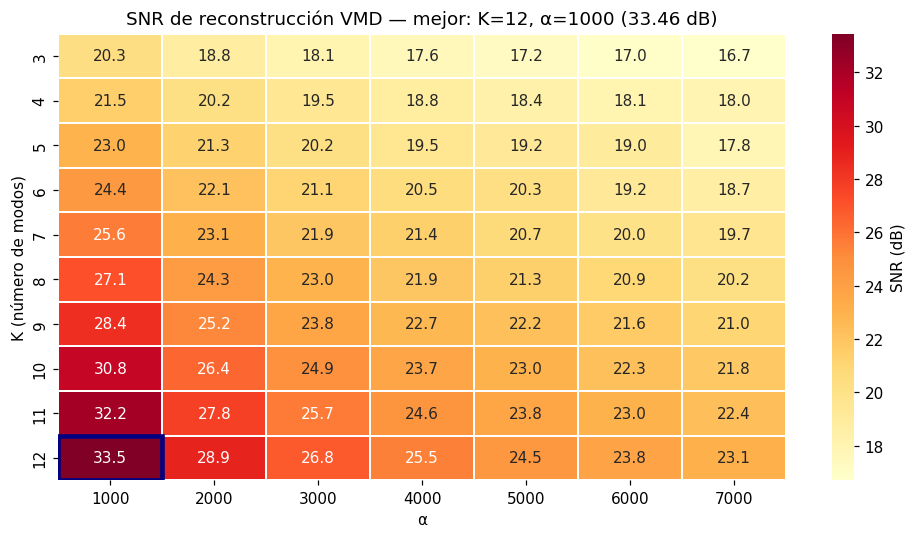

In [ ]:
# ── Heatmap SNR ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
mask = np.isnan(snr_grid)
sns.heatmap(
    snr_grid, annot=True, fmt='.1f', cmap='YlOrRd',
    xticklabels=ALPHA_RANGE, yticklabels=K_RANGE,
    linewidths=0.3, ax=ax, mask=mask, cbar_kws={'label': 'SNR (dB)'}
)
ax.set_xlabel('α')
ax.set_ylabel('K (número de modos)')
ax.set_title(f'SNR de reconstrucción VMD — mejor: K={K_OPT}, α={ALPHA_OPT} ({SNR_BEST:.2f} dB)')

# Marcar la celda óptima
ax.add_patch(plt.Rectangle(
    (best_j, best_i), 1, 1,
    fill=False, edgecolor='navy', lw=3
))
plt.tight_layout()
plt.show()

In [ ]:
# ── Aplicar VMD óptimo a las tres particiones ────────────────────────────────
def apply_vmd(signal: np.ndarray) -> np.ndarray:
    """Aplica VMD con (K_OPT, ALPHA_OPT) y devuelve IMFs (K, N_par)."""
    sig = signal.astype(np.float64)
    if len(sig) % 2:
        sig = sig[:-1]   # VMD requiere longitud par
    u, _, _ = VMD(sig, ALPHA_OPT, VMD_TAU, K_OPT, VMD_DC, VMD_INIT, VMD_TOL)
    return u.astype(np.float32)   # (K, N_par)


print('Aplicando VMD con parámetros óptimos...')
train_imfs = apply_vmd(train_norm[:, CLOSE_IDX])   # (K, N_train)
val_imfs   = apply_vmd(val_norm[:,   CLOSE_IDX])   # (K, N_val)
test_imfs  = apply_vmd(test_norm[:,  CLOSE_IDX])   # (K, N_test)

# Alinear longitudes: VMD recorta 1 punto si la señal es impar
n_tr  = train_imfs.shape[1]
n_val = val_imfs.shape[1]
n_te  = test_imfs.shape[1]

train_norm_v = train_norm[:n_tr]
val_norm_v   = val_norm[:n_val]
test_norm_v  = test_norm[:n_te]

train_scale  = train_scale[:n_tr]
val_scale    = val_scale[:n_val]
test_scale   = test_scale[:n_te]

print(f'IMFs train : {train_imfs.shape}  (K x N_train)')
print(f'IMFs val   : {val_imfs.shape}')
print(f'IMFs test  : {test_imfs.shape}')

Aplicando VMD con parámetros óptimos...
IMFs train : (12, 7792)  (K x N_train)
IMFs val   : (12, 1668)
IMFs test  : (12, 1670)


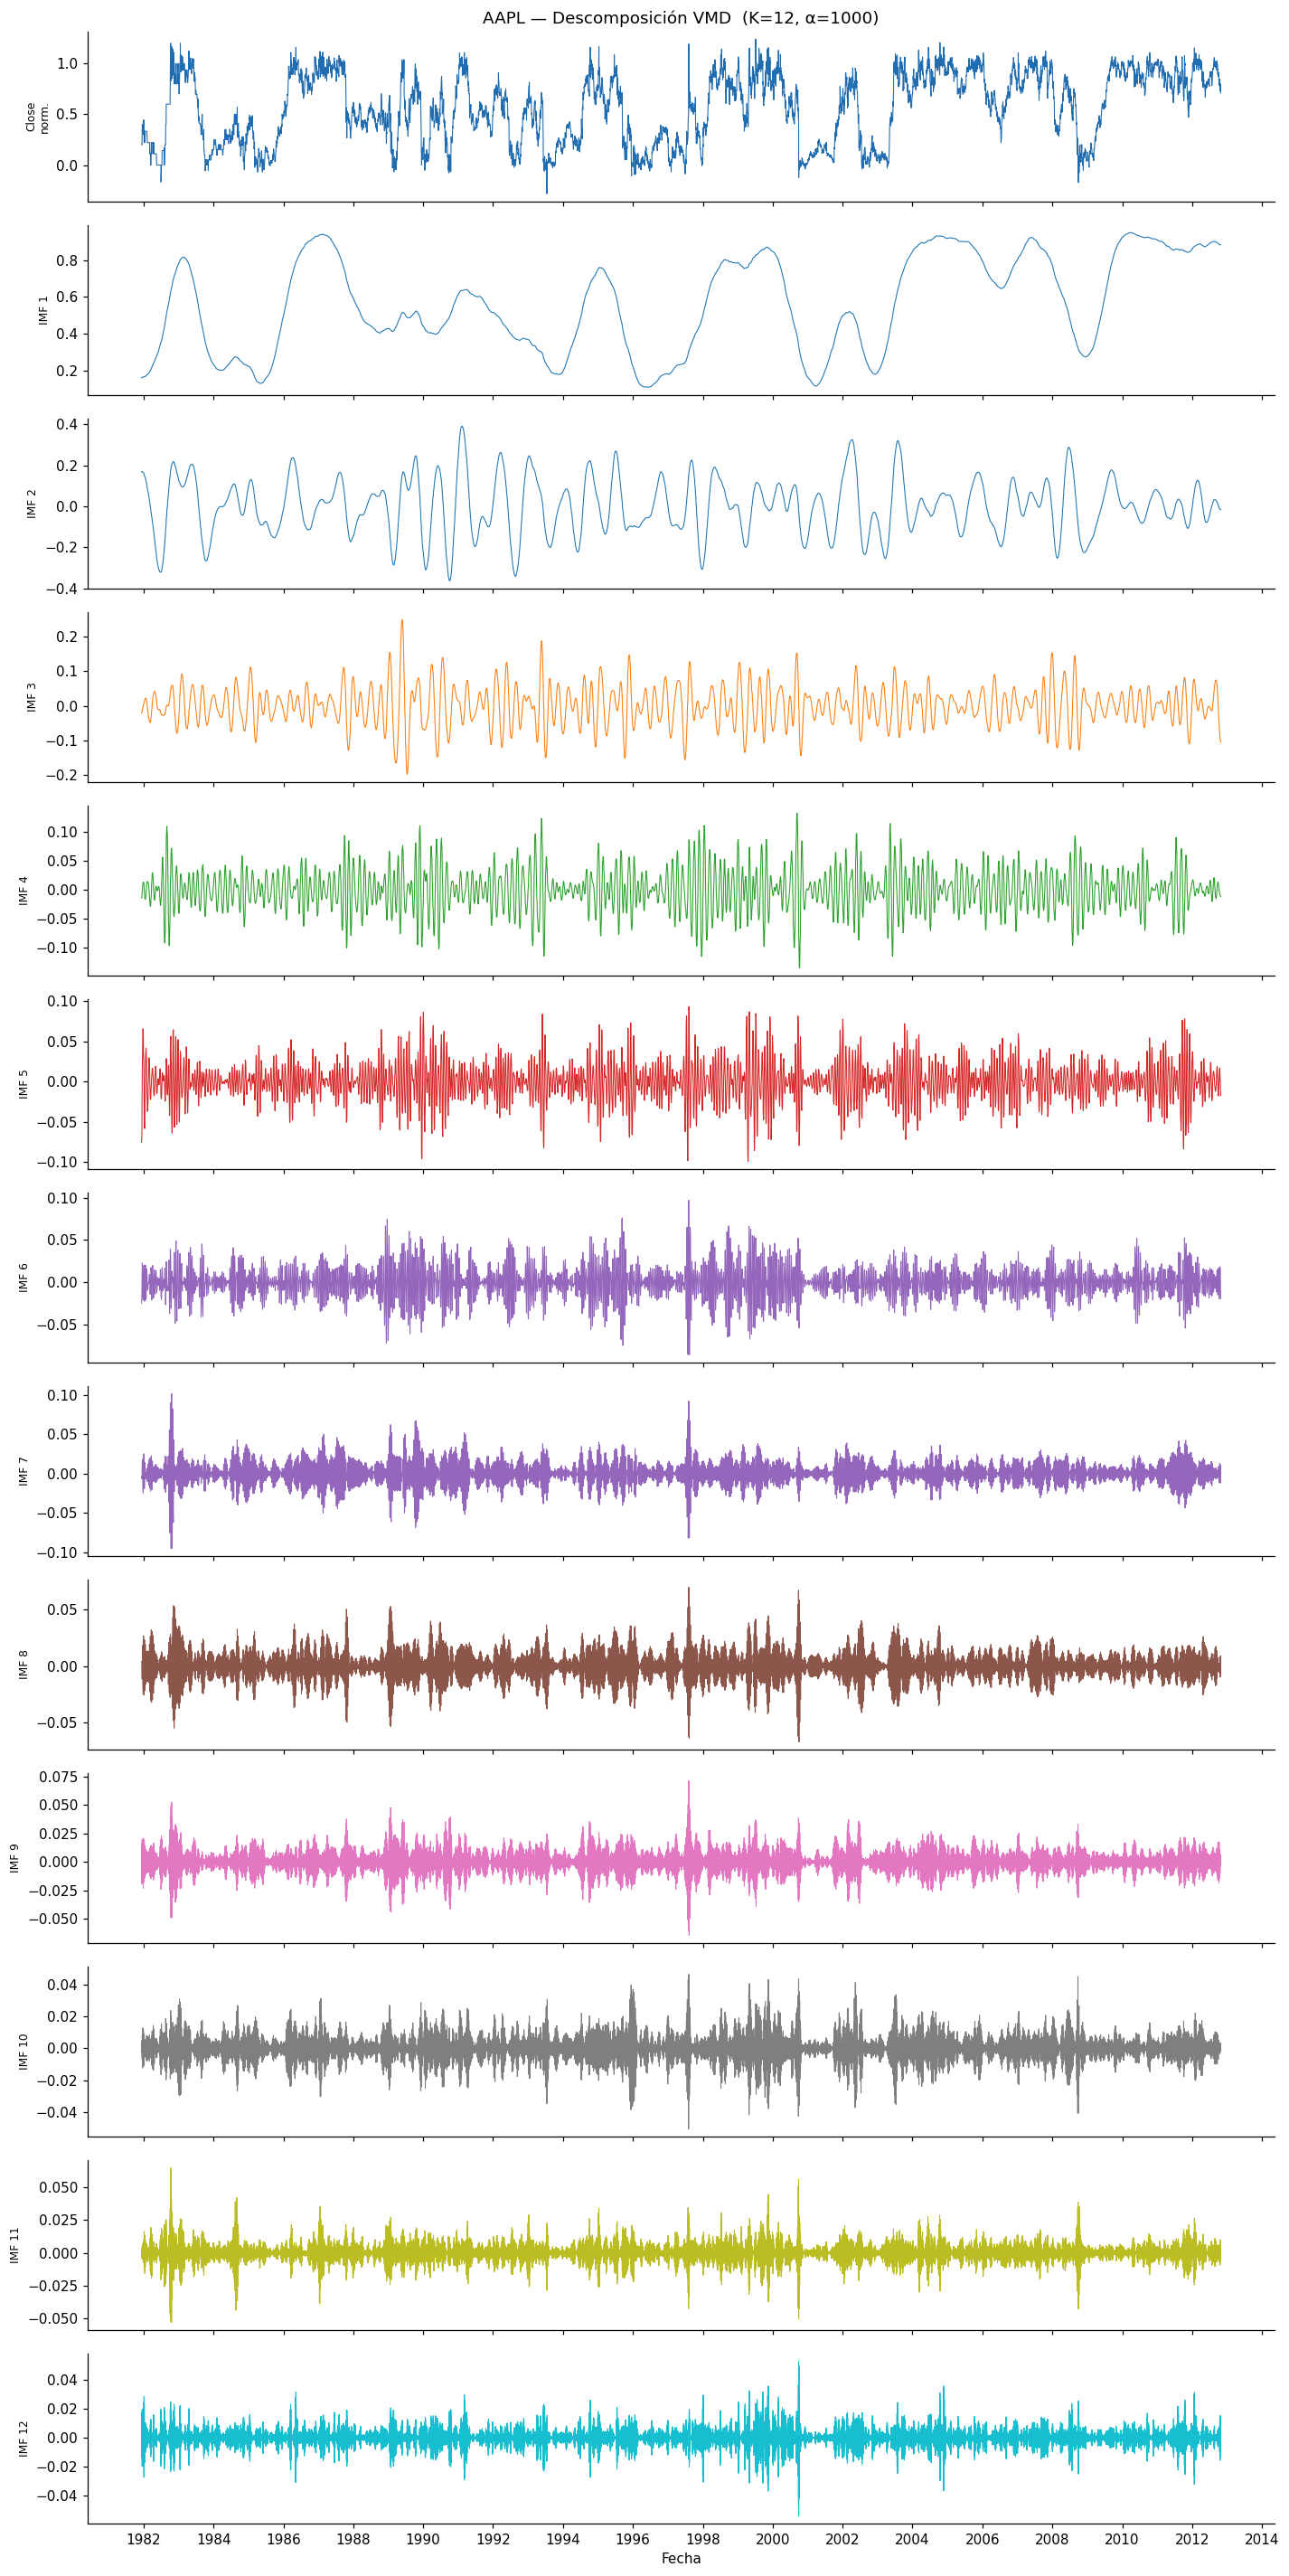

In [ ]:
# ── Visualización de los K_OPT modos (sobre train) ──────────────────────────
fig, axes = plt.subplots(K_OPT + 1, 1, figsize=(13, 2.0 * (K_OPT + 1)), sharex=True)
idx_tr = df_norm.index[:n_tr]

# Señal original
axes[0].plot(idx_tr, train_norm_v[:, CLOSE_IDX], lw=0.7, color='#1f6cb0')
axes[0].set_ylabel('Close\nnorm.', fontsize=8)
axes[0].set_title(f'{TICKER} — Descomposición VMD  (K={K_OPT}, α={ALPHA_OPT})')

colors = plt.cm.tab10(np.linspace(0, 0.9, K_OPT))
for k in range(K_OPT):
    axes[k+1].plot(idx_tr, train_imfs[k], lw=0.7, color=colors[k])
    axes[k+1].set_ylabel(f'IMF {k+1}', fontsize=8)

axes[-1].set_xlabel('Fecha')
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

---
## 6 · Ingeniería de features post-VMD

La matriz de entrada al LSTM combina:
- **K_OPT IMFs** obtenidos de la descomposición del Close normalizado
- **Open, High, Low** normalizados (las otras 3 columnas de `FEATURES`)

Esto da un total de `K_OPT + 3` features por instante temporal.

La función `create_sequences` construye ventanas deslizantes de longitud `time_step`
donde la etiqueta es el valor de Close normalizado en el instante siguiente al fin de la ventana.

In [ ]:
# Índices de Open, High, Low en FEATURES (todo excepto Close)
OHL_IDXS = [i for i, f in enumerate(FEATURES) if f != 'close']  # [0, 1, 2]

# ── Matrices de features [IMF_0..IMF_{K-1}, Open, High, Low] ─────────────────
features_train = np.concatenate([train_imfs.T, train_norm_v[:, OHL_IDXS]], axis=1)  # (N_train, K+3)
features_val   = np.concatenate([val_imfs.T,   val_norm_v[:,   OHL_IDXS]], axis=1)
features_test  = np.concatenate([test_imfs.T,  test_norm_v[:,  OHL_IDXS]], axis=1)

# ── Targets: Close normalizado en t+1 ────────────────────────────────────────
target_train = train_norm[:, CLOSE_IDX]   # (N_train,)
target_val   = val_norm[:,   CLOSE_IDX]
target_test  = test_norm[:,  CLOSE_IDX]

# Número de features de entrada al LSTM (fijo tras VMD)
n_input_features = K_OPT + 3

print(f'Features por timestep : {n_input_features}  (K={K_OPT} IMFs + 3 OHL)')
print(f'features_train shape  : {features_train.shape}')
print(f'features_val shape    : {features_val.shape}')
print(f'features_test shape   : {features_test.shape}')

Features por timestep : 15  (K=12 IMFs + 3 OHL)
features_train shape  : (7792, 15)
features_val shape    : (1668, 15)
features_test shape   : (1670, 15)


In [ ]:
def create_sequences(X: np.ndarray, y: np.ndarray, time_step: int):
    """
    Crea ventanas deslizantes de longitud time_step.

    Parámetros
    ----------
    X         : (N, n_features)
    y         : (N,)  — valores objetivo
    time_step : longitud de la ventana de entrada

    Devuelve
    --------
    Xs : (N - time_step, time_step, n_features)
    ys : (N - time_step,)  —  y[t + time_step] para cada muestra
    """
    Xs, ys = [], []
    for i in range(len(X) - time_step):
        Xs.append(X[i : i + time_step])
        ys.append(y[i + time_step])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


# Previsualización con un time_step provisional
_ts_preview = 10
_Xp, _yp = create_sequences(features_train, target_train, _ts_preview)
print(f'Previsualización con time_step={_ts_preview}:')
print(f'  X shape : {_Xp.shape}  →  (muestras, time_step, n_features)')
print(f'  y shape : {_yp.shape}')
del _Xp, _yp

Previsualización con time_step=10:
  X shape : (7782, 10, 15)  →  (muestras, time_step, n_features)
  y shape : (7782,)


---
## 7 · Optimización de hiperparámetros LSTM con SSA (DevSSA)

El **Sparrow Search Algorithm** (variante `DevSSA`, numéricamente más estable) optimiza
los 7 hiperparámetros del LSTM minimizando el RMSE sobre el conjunto de validación.

| Hiperparámetro | Tipo | Rango |
|---|---|---|
| Learning rate | FloatVar | [0.001, 0.01] |
| Epochs | IntegerVar | [10, 100] |
| Time step | IntegerVar | [1, 20] |
| Capas LSTM | IntegerVar | [1, 3] |
| Unidades/capa | IntegerVar | [1, 100] |
| Unidades dense | IntegerVar | [1, 100] |
| Dropout | FloatVar | [0.1, 0.5] |

> **Nota:** esta sección es la más costosa computacionalmente. Reducir `SSA_POP_SIZE` y `SSA_EPOCH` para exploración rápida.

In [ ]:
class LSTMModel(nn.Module):
    """
    LSTM multivariante configurable.

    Parámetros
    ----------
    input_size  : número de features por timestep
    hidden_size : unidades por capa LSTM
    num_layers  : número de capas LSTM apiladas
    dense_units : unidades de la capa densa intermedia
    dropout     : tasa de dropout entre capas LSTM (y antes del output)
    """
    def __init__(self, input_size: int, hidden_size: int,
                 num_layers: int, dense_units: int, dropout: float):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=lstm_dropout
        )
        self.fc1     = nn.Linear(hidden_size, dense_units)
        self.act     = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(dense_units, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _  = self.lstm(x)
        out     = out[:, -1, :]          # último timestep
        out     = self.act(self.fc1(out))
        out     = self.dropout(out)
        return self.fc_out(out).squeeze(-1)


print('Clase LSTMModel definida.')

Clase LSTMModel definida.


In [ ]:
def train_lstm(model, X_tr, y_tr, epochs, lr, batch_size=32):
    """Bucle de entrenamiento compacto para usar dentro del fitness."""
    dataset   = TensorDataset(
        torch.FloatTensor(X_tr).to(DEVICE),
        torch.FloatTensor(y_tr).to(DEVICE)
    )
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()


def fitness_function(solution: np.ndarray) -> float:
    """
    Función objetivo para DevSSA.
    Recibe el vector continuo y decodifica manualmente cada hiperparámetro.
    Devuelve RMSE sobre validación (a minimizar).
    """
    # ── Decodificación (IntegerVar trabaja internamente en float con ±0.5) ───
    lr        = float(np.clip(solution[0], 0.001, 0.01))
    epochs    = int(np.clip(round(solution[1]),  10,  100))
    time_step = int(np.clip(round(solution[2]),   1,   20))
    n_layers  = int(np.clip(round(solution[3]),   1,    3))
    units     = int(np.clip(round(solution[4]),   1,  100))
    dense     = int(np.clip(round(solution[5]),   1,  100))
    dropout   = float(np.clip(solution[6], 0.1, 0.5))

    # ── Construir secuencias con el time_step propuesto ──────────────────────
    X_tr, y_tr  = create_sequences(features_train, target_train, time_step)
    X_val, y_val = create_sequences(features_val,  target_val,   time_step)

    if len(X_tr) < 16 or len(X_val) < 4:
        return 1e6   # combinación inviable

    # ── Entrenar con semilla fija para reproducibilidad ──────────────────────
    torch.manual_seed(SEED)
    model = LSTMModel(n_input_features, units, n_layers, dense, dropout).to(DEVICE)
    train_lstm(model, X_tr, y_tr, epochs, lr)

    # ── Evaluar en validación ────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        X_val_t  = torch.FloatTensor(X_val).to(DEVICE)
        val_pred = model(X_val_t).cpu().numpy()

    rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
    return rmse


print('Función de fitness definida.')

Función de fitness definida.


In [ ]:
# ── Espacio de búsqueda SSA (bounds mixtos: FloatVar + IntegerVar) ────────────
ssa_bounds = [
    FloatVar(  lb=0.001, ub=0.01,  name='learning_rate'),
    IntegerVar(lb=10,    ub=100,   name='epochs'),
    IntegerVar(lb=1,     ub=20,    name='time_step'),
    IntegerVar(lb=1,     ub=3,     name='n_lstm_layers'),
    IntegerVar(lb=1,     ub=100,   name='units_per_layer'),
    IntegerVar(lb=1,     ub=100,   name='dense_units'),
    FloatVar(  lb=0.1,  ub=0.5,   name='dropout_rate'),
]

ssa_problem = {
    'obj_func': fitness_function,
    'bounds'  : ssa_bounds,
    'minmax'  : 'min',      # minimizar RMSE
    'log_to'  : None,       # silenciar logs internos de mealpy
}

# ══════════════════════════════════════════════════════════════════════
#  Parámetros del optimizador SSA
#  Exploración rápida : SSA_POP_SIZE=10, SSA_EPOCH=15
#  Búsqueda completa  : SSA_POP_SIZE=25, SSA_EPOCH=40
# ══════════════════════════════════════════════════════════════════════
SSA_POP_SIZE = 10
SSA_EPOCH    = 15

print(f'Evaluaciones totales estimadas: {SSA_POP_SIZE * SSA_EPOCH}')
print(f'Iniciando DevSSA  (pop={SSA_POP_SIZE}, epoch={SSA_EPOCH}) ...')

t_ssa_start = time.time()

ssa_model = SSA.DevSSA(
    epoch    = SSA_EPOCH,
    pop_size = SSA_POP_SIZE,
    ST = 0.8,   # safety threshold
    PD = 0.2,   # proporción de productores
    SD = 0.1    # proporción de sparrows en alerta
)
g_best = ssa_model.solve(ssa_problem)

t_ssa = time.time() - t_ssa_start
print(f'\nSSA completado en {t_ssa:.1f}s ({t_ssa/60:.1f} min)')
print(f'Mejor RMSE (val normalizado): {g_best.target.fitness:.6f}')

Evaluaciones totales estimadas: 150
Iniciando DevSSA  (pop=10, epoch=15) ...

SSA completado en 15568.5s (259.5 min)
Mejor RMSE (val normalizado): 0.010324


Hiperparámetros óptimos encontrados por SSA (DevSSA):
─────────────────────────────────────────────
  learning_rate       : 0.008965878108681017
  epochs              : 85
  time_step           : 6
  n_lstm_layers       : 1
  units_per_layer     : 54
  dense_units         : 67
  dropout_rate        : 0.3874990617889641
─────────────────────────────────────────────
  RMSE val (norm.)    : 0.010324


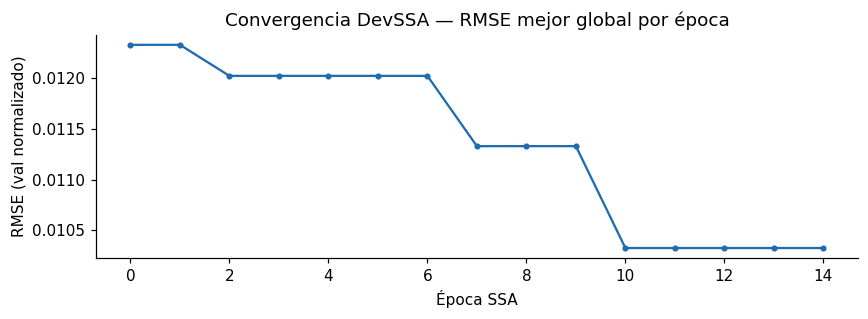

In [ ]:
# ── Extraer hiperparámetros óptimos ─────────────────────────────────────────
sol = g_best.solution

BEST_PARAMS = {
    'learning_rate' : float(np.clip(sol[0], 0.001, 0.01)),
    'epochs'        : int(np.clip(round(sol[1]),  10,  100)),
    'time_step'     : int(np.clip(round(sol[2]),   1,   20)),
    'n_lstm_layers' : int(np.clip(round(sol[3]),   1,    3)),
    'units_per_layer': int(np.clip(round(sol[4]),  1,  100)),
    'dense_units'   : int(np.clip(round(sol[5]),   1,  100)),
    'dropout_rate'  : float(np.clip(sol[6], 0.1, 0.5)),
}

print('Hiperparámetros óptimos encontrados por SSA (DevSSA):')
print('─' * 45)
for k, v in BEST_PARAMS.items():
    print(f'  {k:<20}: {v}')
print('─' * 45)
print(f'  RMSE val (norm.)    : {g_best.target.fitness:.6f}')

# ── Convergencia del SSA ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ssa_model.history.list_global_best_fit, lw=1.5, color='#1f6cb0', marker='o', ms=3)
ax.set_title('Convergencia DevSSA — RMSE mejor global por época')
ax.set_xlabel('Época SSA')
ax.set_ylabel('RMSE (val normalizado)')
plt.tight_layout()
plt.show()

---
## 8 · Entrenamiento del modelo LSTM final

Se entrena el modelo con los hiperparámetros óptimos del SSA usando los conjuntos
completos de train y validación. Se monitoriza la pérdida por época.

In [ ]:
# ── Construir secuencias con el time_step óptimo ────────────────────────────
TS = BEST_PARAMS['time_step']

X_train, y_train = create_sequences(features_train, target_train, TS)
X_val,   y_val   = create_sequences(features_val,   target_val,   TS)
X_test,  y_test  = create_sequences(features_test,  target_test,  TS)

# Los índices de test_scale deben coincidir con los targets en y_test
# y_test[i] = target_test[i + TS], que corresponde a test_scale[i + TS]
test_scale_seq = test_scale[TS:]   # escala para la transformación inversa

print(f'time_step   : {TS}')
print(f'X_train     : {X_train.shape}')
print(f'X_val       : {X_val.shape}')
print(f'X_test      : {X_test.shape}')

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 32
train_ds   = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_ds     = TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val))
train_dl   = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl     = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

time_step   : 6
X_train     : (7786, 6, 15)
X_val       : (1662, 6, 15)
X_test      : (1664, 6, 15)


In [ ]:
# ── Instanciar modelo final ──────────────────────────────────────────────────
torch.manual_seed(SEED)
final_model = LSTMModel(
    input_size   = n_input_features,
    hidden_size  = BEST_PARAMS['units_per_layer'],
    num_layers   = BEST_PARAMS['n_lstm_layers'],
    dense_units  = BEST_PARAMS['dense_units'],
    dropout      = BEST_PARAMS['dropout_rate']
).to(DEVICE)

total_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)
print(final_model)
print(f'\nParámetros entrenables: {total_params:,}')

LSTMModel(
  (lstm): LSTM(15, 54, batch_first=True)
  (fc1): Linear(in_features=54, out_features=67, bias=True)
  (act): ReLU()
  (dropout): Dropout(p=0.3874990617889641, inplace=False)
  (fc_out): Linear(in_features=67, out_features=1, bias=True)
)

Parámetros entrenables: 19,089


In [ ]:
# ── Bucle de entrenamiento con registro de métricas ─────────────────────────
EPOCHS    = BEST_PARAMS['epochs']
LR        = BEST_PARAMS['learning_rate']
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=LR)

train_losses, val_losses = [], []
t_train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    final_model.train()
    running_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(xb)
    train_losses.append(running_loss / len(train_ds))

    # ── Validación ───────────────────────────────────────────────────────────
    final_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(final_model(xb), yb).item() * len(xb)
    val_losses.append(val_loss / len(val_ds))

    if epoch % max(1, EPOCHS // 10) == 0 or epoch == EPOCHS:
        print(f'Epoch {epoch:4d}/{EPOCHS}  '
              f'train_loss={train_losses[-1]:.6f}  '
              f'val_loss={val_losses[-1]:.6f}')

t_train = time.time() - t_train_start
print(f'\nEntrenamiento completado en {t_train:.1f}s')

Epoch    8/85  train_loss=0.004212  val_loss=0.002097
Epoch   16/85  train_loss=0.003887  val_loss=0.000450
Epoch   24/85  train_loss=0.003980  val_loss=0.000205
Epoch   32/85  train_loss=0.003877  val_loss=0.002725
Epoch   40/85  train_loss=0.003797  val_loss=0.001106
Epoch   48/85  train_loss=0.003693  val_loss=0.000296
Epoch   56/85  train_loss=0.003722  val_loss=0.000447
Epoch   64/85  train_loss=0.003623  val_loss=0.000372
Epoch   72/85  train_loss=0.003901  val_loss=0.002050
Epoch   80/85  train_loss=0.003927  val_loss=0.000579
Epoch   85/85  train_loss=0.003857  val_loss=0.000381

Entrenamiento completado en 57.4s


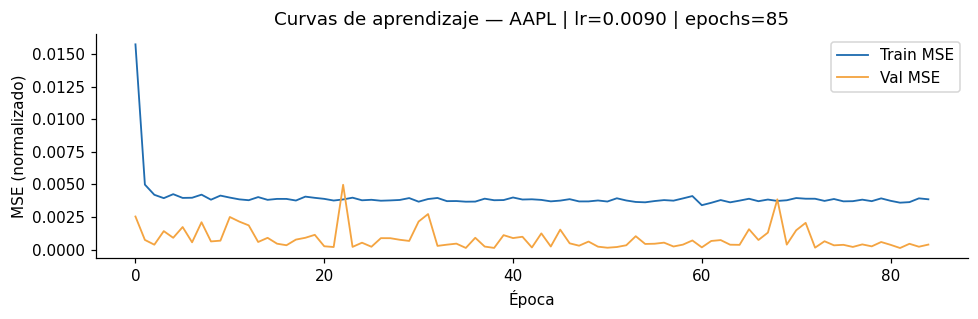

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(train_losses, lw=1.2, color='#1f6cb0', label='Train MSE')
ax.plot(val_losses,   lw=1.2, color='#f4a441', label='Val MSE')
ax.set_title(f'Curvas de aprendizaje — {TICKER} | lr={LR:.4f} | epochs={EPOCHS}')
ax.set_xlabel('Época')
ax.set_ylabel('MSE (normalizado)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9 · Evaluación y clasificación de tendencia

Se evalúa el modelo sobre el conjunto de **test** (nunca visto durante el entrenamiento ni la optimización).

**Métricas de regresión:** RMSE, MAE, MAPE, R², Runtime total del pipeline.

**Clasificación de tendencia** (3 clases): a partir del precio predicho en `t+1` y el precio real en `t`,
se calcula el cambio porcentual y se asigna:
- **ALCISTA** si `Δ% > +TREND_THRESHOLD`
- **BAJISTA** si `Δ% < -TREND_THRESHOLD`
- **NEUTRAL** en caso contrario

In [ ]:
t_inference_start = time.time()

# ── Predicciones (escala normalizada) ────────────────────────────────────────
final_model.eval()
with torch.no_grad():
    X_test_t   = torch.FloatTensor(X_test).to(DEVICE)
    y_pred_norm = final_model(X_test_t).cpu().numpy()   # (N_test_seq,)

t_inference = time.time() - t_inference_start

# ── Transformación inversa a precios reales ───────────────────────────────────
# test_scale_seq[i] contiene (w_min, w_max) para el punto target en y_test[i]
assert len(test_scale_seq) >= len(y_pred_norm), 'Discrepancia en scale_params'

y_pred_real = np.array([
    inverse_transform_close(y_pred_norm[i], test_scale_seq[i])
    for i in range(len(y_pred_norm))
])
y_true_real = np.array([
    inverse_transform_close(y_test[i], test_scale_seq[i])
    for i in range(len(y_test))
])

print(f'Muestras test evaluadas : {len(y_pred_real)}')
print(f'Tiempo de inferencia    : {t_inference*1000:.1f} ms')

Muestras test evaluadas : 1664
Tiempo de inferencia    : 2.9 ms


In [ ]:
# ── Métricas de regresión ───────────────────────────────────────────────────
RMSE    = float(np.sqrt(mean_squared_error(y_true_real, y_pred_real)))
MAE     = float(mean_absolute_error(y_true_real, y_pred_real))
MAPE    = float(np.mean(np.abs((y_true_real - y_pred_real) /
                                (y_true_real + 1e-8))) * 100)
R2      = float(r2_score(y_true_real, y_pred_real))
RUNTIME = t_ssa + t_train + t_inference   # total pipeline (excluye VMD grid search)

print('══════════════════════════════════════════')
print('   MÉTRICAS DE REGRESIÓN — TEST SET')
print('══════════════════════════════════════════')
print(f'  RMSE     : {RMSE:.4f} $')
print(f'  MAE      : {MAE:.4f} $')
print(f'  MAPE     : {MAPE:.4f} %')
print(f'  R²       : {R2:.4f}')
print(f'  Runtime  : {RUNTIME:.1f}s  (SSA {t_ssa:.0f}s + train {t_train:.0f}s + infer {t_inference*1000:.0f}ms)')
print('══════════════════════════════════════════')

══════════════════════════════════════════
   MÉTRICAS DE REGRESIÓN — TEST SET
══════════════════════════════════════════
  RMSE     : 1.3900 $
  MAE      : 1.1135 $
  MAPE     : 0.7341 %
  R²       : 0.9994
  Runtime  : 15625.9s  (SSA 15569s + train 57s + infer 3ms)
══════════════════════════════════════════


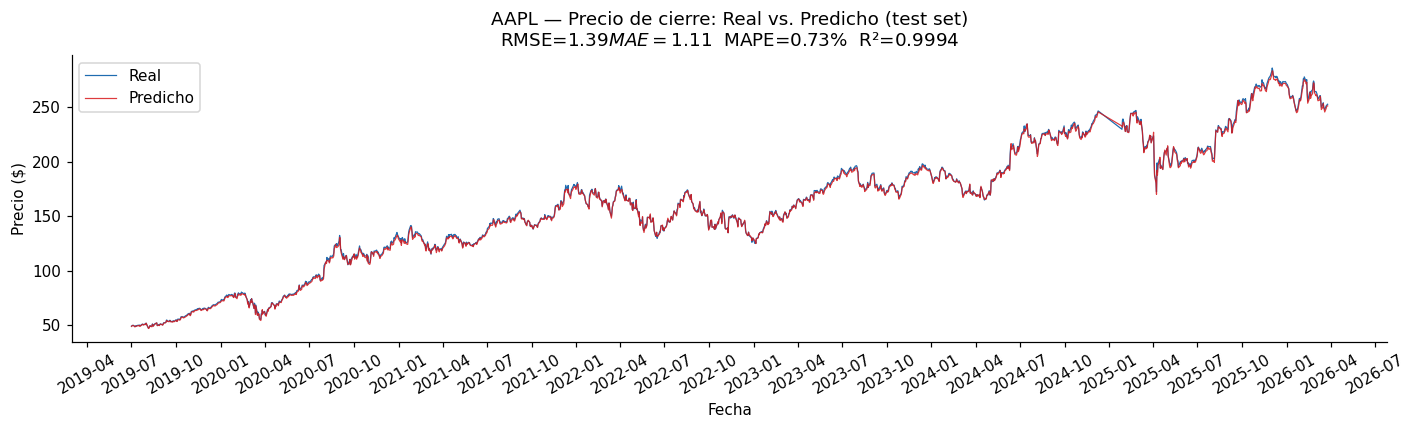

In [ ]:
# ── Visualización precios reales vs. predichos ───────────────────────────────
test_dates_seq = df_norm.index[n_tr2 + n_val2 + TS:]
test_dates_seq = test_dates_seq[:len(y_pred_real)]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_dates_seq, y_true_real, lw=0.8, color='#1f6cb0', label='Real')
ax.plot(test_dates_seq, y_pred_real, lw=0.8, color='#d7191c', label='Predicho', alpha=0.85)
ax.set_title(f'{TICKER} — Precio de cierre: Real vs. Predicho (test set)\n'
             f'RMSE={RMSE:.2f}$  MAE={MAE:.2f}$  MAPE={MAPE:.2f}%  R²={R2:.4f}')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ($)')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  CLASIFICACIÓN DE TENDENCIA  (3 clases)
# ═══════════════════════════════════════════════════════════════════════════

# ── Parámetro de umbral ──────────────────────────────────────────────────────
TREND_THRESHOLD = 0.5   # % — ajustar según volatilidad del activo

# Precio real en t (día actual, un paso antes del target t+1)
# test_scale_seq[i] → escala del target (t+1)
# Necesitamos la escala del actual (t), que es test_scale_seq[i-1] para i>0
# O directamente usamos y_true_real shifteado un paso atrás como proxy del precio actual
actual_t  = y_true_real[:-1]   # precio en t  (días actuales)
pred_t1   = y_pred_real[1:]    # predicción en t+1
true_t1   = y_true_real[1:]    # real en t+1 (para calcular accuracy)

# Cambio porcentual predicho
pct_change_pred = (pred_t1 - actual_t) / (actual_t + 1e-8) * 100
pct_change_true = (true_t1 - actual_t) / (actual_t + 1e-8) * 100

LABELS = ['BAJISTA', 'NEUTRAL', 'ALCISTA']

def classify(pct: np.ndarray, threshold: float) -> np.ndarray:
    out = np.full(len(pct), 1, dtype=int)            # 1 = NEUTRAL
    out[pct >  threshold] = 2                        # 2 = ALCISTA
    out[pct < -threshold] = 0                        # 0 = BAJISTA
    return out

trend_pred = classify(pct_change_pred, TREND_THRESHOLD)
trend_true = classify(pct_change_true, TREND_THRESHOLD)

print(f'Umbral de tendencia: ±{TREND_THRESHOLD}%')
print(f'Distribución clases verdaderas : {dict(zip(LABELS, np.bincount(trend_true, minlength=3)))}')
print(f'Distribución clases predichas  : {dict(zip(LABELS, np.bincount(trend_pred, minlength=3)))}')

Umbral de tendencia: ±0.5%
Distribución clases verdaderas : {'BAJISTA': 535, 'NEUTRAL': 482, 'ALCISTA': 646}
Distribución clases predichas  : {'BAJISTA': 865, 'NEUTRAL': 434, 'ALCISTA': 364}



Accuracy direccional : 63.50%
F1-score macro       : 0.6126
F1 por clase: BAJISTA=0.7486  NEUTRAL=0.3843  ALCISTA=0.7050


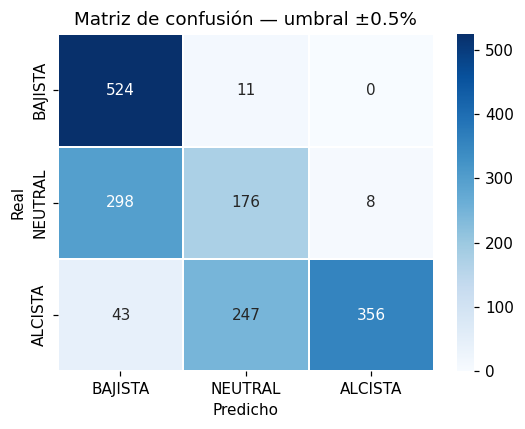

In [ ]:
# ── Métricas de clasificación ────────────────────────────────────────────────
acc      = float(np.mean(trend_pred == trend_true))
f1_macro = float(f1_score(trend_true, trend_pred, average='macro',  zero_division=0))
f1_each  = f1_score(trend_true, trend_pred, average=None, labels=[0,1,2], zero_division=0)
cm       = confusion_matrix(trend_true, trend_pred, labels=[0,1,2])

print(f'\nAccuracy direccional : {acc*100:.2f}%')
print(f'F1-score macro       : {f1_macro:.4f}')
print(f'F1 por clase: BAJISTA={f1_each[0]:.4f}  NEUTRAL={f1_each[1]:.4f}  ALCISTA={f1_each[2]:.4f}')

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax,
            linewidths=0.3)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión — umbral ±{TREND_THRESHOLD}%')
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  RESUMEN FINAL
# ═══════════════════════════════════════════════════════════════════════════
summary = pd.DataFrame({
    'Componente': [
        'Ticker', 'Observaciones (limpias)', 'Ventana normalización',
        'VMD — K óptimo', 'VMD — α óptimo', 'VMD — SNR (dB)',
        'SSA — epochs', 'SSA — pop size',
        '── Hiperparámetros LSTM ──',
        'Learning rate', 'Epochs', 'Time step',
        'Capas LSTM', 'Unidades/capa', 'Unidades dense', 'Dropout',
        '── Métricas test ──',
        'RMSE ($)', 'MAE ($)', 'MAPE (%)', 'R²',
        'Accuracy direccional (%)', 'F1 macro',
        'Runtime pipeline (s)',
    ],
    'Valor': [
        TICKER, len(df), WINDOW_SIZE,
        K_OPT, ALPHA_OPT, f'{SNR_BEST:.2f}',
        SSA_EPOCH, SSA_POP_SIZE,
        '',
        f'{BEST_PARAMS["learning_rate"]:.5f}',
        BEST_PARAMS['epochs'],
        BEST_PARAMS['time_step'],
        BEST_PARAMS['n_lstm_layers'],
        BEST_PARAMS['units_per_layer'],
        BEST_PARAMS['dense_units'],
        f'{BEST_PARAMS["dropout_rate"]:.2f}',
        '',
        f'{RMSE:.4f}', f'{MAE:.4f}', f'{MAPE:.4f}', f'{R2:.4f}',
        f'{acc*100:.2f}', f'{f1_macro:.4f}',
        f'{RUNTIME:.1f}',
    ]
})

display(summary.style.set_properties(**{'text-align': 'left'}))

# Guardar resumen en CSV
summary.to_csv(f'{TICKER}_vmd_ssa_lstm_results.csv', index=False)
print(f'\nResultados guardados en {TICKER}_vmd_ssa_lstm_results.csv')

,Componente,Valor
0,Ticker,AAPL
1,Observaciones (limpias),11385
2,Ventana normalización,252
3,VMD — K óptimo,12
4,VMD — α óptimo,1000
5,VMD — SNR (dB),33.46
6,SSA — epochs,15
7,SSA — pop size,10
8,── Hiperparámetros LSTM ──,
9,Learning rate,0.00897



Resultados guardados en AAPL_vmd_ssa_lstm_results.csv
